# Fort Assessment — Signal Quality & IMU Demo

Two demonstrations:
1. **Q3 — SQI pipeline on real PPG data** (PPG-DaLiA dataset: PPG + ACC + ECG reference across eight daily-life activities plus transitions)
2. **Q2 — Rep counting and velocity drift on synthetic IMU data**

Requires: `data/PPG_FieldStudy/S1/S1.pkl` — see README for dataset download.

In [1]:
import warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pickle
from scipy.signal import butter, filtfilt, welch, find_peaks

# The PPG-DaLiA pickles were written under an older numpy; loading them under
# numpy 2.x raises a harmless dtype-alignment deprecation notice. Silence just that.
warnings.filterwarnings('ignore', message=r'dtype\(\): align')

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

---
## Part 1: SQI Pipeline on Real PPG Data (Q3)

**Dataset**: PPG-DaLiA (Reiss et al., 2019) — 15 subjects, PPG at 64 Hz, 3-axis ACC at 32 Hz, ECG reference at 700 Hz, across eight daily-life activities (sitting, stairs, table soccer, cycling, driving, lunch, walking, working) plus transition periods.

**Goal**: Show that the SQI features track signal quality intuitively across activities, and that SQI-gated HR estimation outperforms naive estimation on noisy windows.

In [2]:
# --- Load subject data ---
import pandas as pd

SUBJECT = 'S1'
with open(f'data/PPG_FieldStudy/{SUBJECT}/{SUBJECT}.pkl', 'rb') as f:
    data = pickle.load(f, encoding='latin1')

ppg    = data['signal']['wrist']['BVP'].flatten()   # 64 Hz
acc    = data['signal']['wrist']['ACC']              # 32 Hz, (N, 3)
gt_hr  = data['label']                               # ECG-derived HR, one per 2s window
fs_ppg = 64
fs_acc = 32

# Parse activity labels from CSV (timestamps in seconds)
ACTIVITY_NAMES = {
    '# BASELINE': 'Baseline', '# STAIRS': 'Stairs', '# SOCCER': 'Table soccer',
    '# CYCLING': 'Cycling',   '# DRIVING': 'Driving', '# LUNCH': 'Lunch break',
    '# WALKING': 'Walking',   '# WORKING': 'Working', '# NO_ACTIVITY': 'Transition',
    '# CLEAN_BASELINE': 'Baseline'
}
act_csv = pd.read_csv(f'data/PPG_FieldStudy/{SUBJECT}/{SUBJECT}_activity.csv', header=None)
act_csv.columns = ['name', 'start_sec']
act_csv = act_csv[act_csv['name'].str.startswith('#')]
act_csv['label'] = act_csv['name'].map(ACTIVITY_NAMES).fillna('Other')
act_csv['start_sec'] = pd.to_numeric(act_csv['start_sec'], errors='coerce')
act_csv = act_csv.dropna(subset=['start_sec']).reset_index(drop=True)

# Build per-sample activity array (one label per PPG sample)
n_samples  = len(ppg)
act_labels = np.full(n_samples, 'Transition', dtype=object)
for i, row in act_csv.iterrows():
    start = int(row['start_sec'] * fs_ppg)
    end   = int(act_csv.iloc[i+1]['start_sec'] * fs_ppg) if i+1 < len(act_csv) else n_samples
    act_labels[start:end] = row['label']

print(f'PPG samples : {n_samples:,}  ({n_samples/fs_ppg/60:.1f} min)')
print(f'GT HR windows: {len(gt_hr)}  (2s each, ECG-derived)')
print(f'Activities  : {list(dict.fromkeys(act_labels))}')

PPG samples : 589,568  (153.5 min)
GT HR windows: 4603  (2s each, ECG-derived)
Activities  : ['Transition', 'Baseline', 'Stairs', 'Table soccer', 'Cycling', 'Driving', 'Lunch break', 'Walking', 'Working']


In [3]:
# --- Signal quality index (SQI) ---

def bandpass(sig, lo, hi, fs, order=4):
    b, a = butter(order, [lo / (fs/2), hi / (fs/2)], btype='band')
    return filtfilt(b, a, sig)

def compute_sqi(ppg_win, acc_win, fs=64):
    """
    Three lightweight features -> continuous SQI score [0, 1]. Cheap enough to run
    first and gate the downstream cascade.

    1. Cardiac peak SNR : power in a narrow band around the dominant cardiac peak
                          (+ its 1st harmonic) divided by total spectral power over
                          0.5-8 Hz. The denominator spans a WIDER band than the
                          numerator on purpose: an earlier version measured in-band
                          power after band-passing to that same band, which is ~0.99
                          for every window and carries no information. This version
                          rewards a sharp, dominant cardiac peak over broadband noise.
    2. Autocorrelation  : peak at the expected cardiac lag (0.3-1.5 s) -> periodicity.
    3. Motion penalty   : exp decay with ACC magnitude std. scale=0.5 chosen for the
                          PPG-DaLiA ACC range (std up to ~0.6 g). This is a cheap proxy;
                          a cleaner feature is PPG-ACC spectral coherence (does the PPG
                          spectral peak coincide with a motion peak?), but it was numer-
                          ically unstable on zero-variance windows, so I kept the proxy.
    """
    # 1. Cardiac peak SNR
    ppg_w = bandpass(ppg_win, 0.5, 8.0, fs)
    freqs, psd = welch(ppg_w, fs=fs, nperseg=min(fs * 4, len(ppg_w)))
    band = (freqs >= 0.5) & (freqs <= 8.0)
    f, p = freqs[band], psd[band]
    card = (f >= 0.7) & (f <= 3.5)
    peak_f = f[card][np.argmax(p[card])]
    near = lambda c: (f >= c - 0.25) & (f <= c + 0.25)
    snr = float(np.clip((p[near(peak_f)].sum() + p[near(2 * peak_f)].sum())
                        / (p.sum() + 1e-9), 0, 1))

    # 2. Autocorrelation at expected cardiac lag (cardiac band)
    ppg_f = bandpass(ppg_win, 0.5, 4.0, fs)
    ac = np.correlate(ppg_f, ppg_f, mode='full')[len(ppg_f) - 1:]
    ac = ac / (ac[0] + 1e-9)
    lo_lag, hi_lag = int(0.3 * fs), min(int(1.5 * fs), len(ac) - 1)
    peak_ac = float(np.clip(ac[lo_lag:hi_lag].max() if hi_lag > lo_lag else 0.0, 0, 1))

    # 3. Motion penalty
    if len(acc_win) > 0:
        motion = np.linalg.norm(acc_win, axis=1).std()
        motion_score = float(np.exp(-motion / 0.5))
    else:
        motion_score = 0.5

    # Geometric mean of three [0,1] features
    return float(np.clip((snr * peak_ac * motion_score) ** (1/3), 0, 1))

# --- Slide across the session ---
# STRIDE = 2s = 128 samples -> one SQI per GT-HR label window
WINDOW = 8 * fs_ppg    # 8 seconds = 512 samples
STRIDE = 2 * fs_ppg    # 2 seconds = 128 samples (aligns with gt_hr labels)

sqis, window_acts, window_times = [], [], []

for start in range(0, len(ppg) - WINDOW, STRIDE):
    ppg_win   = ppg[start : start + WINDOW]
    acc_start = int(start * fs_acc / fs_ppg)
    acc_win   = acc[acc_start : acc_start + int(WINDOW * fs_acc / fs_ppg)]
    sqis.append(compute_sqi(ppg_win, acc_win, fs_ppg))
    window_acts.append(act_labels[start + WINDOW // 2])
    window_times.append(start / fs_ppg / 60)

sqis        = np.array(sqis)
window_acts = np.array(window_acts)

print(f'Windows computed : {len(sqis)}')
print(f'Mean SQI         : {sqis.mean():.3f}')
print(f'Below 0.4 (suppress): {(sqis < 0.4).mean()*100:.1f}%')
print(f'Below 0.7 (noisy)   : {(sqis < 0.7).mean()*100:.1f}%')

Windows computed : 4602
Mean SQI         : 0.610
Below 0.4 (suppress): 9.0%
Below 0.7 (noisy)   : 71.3%


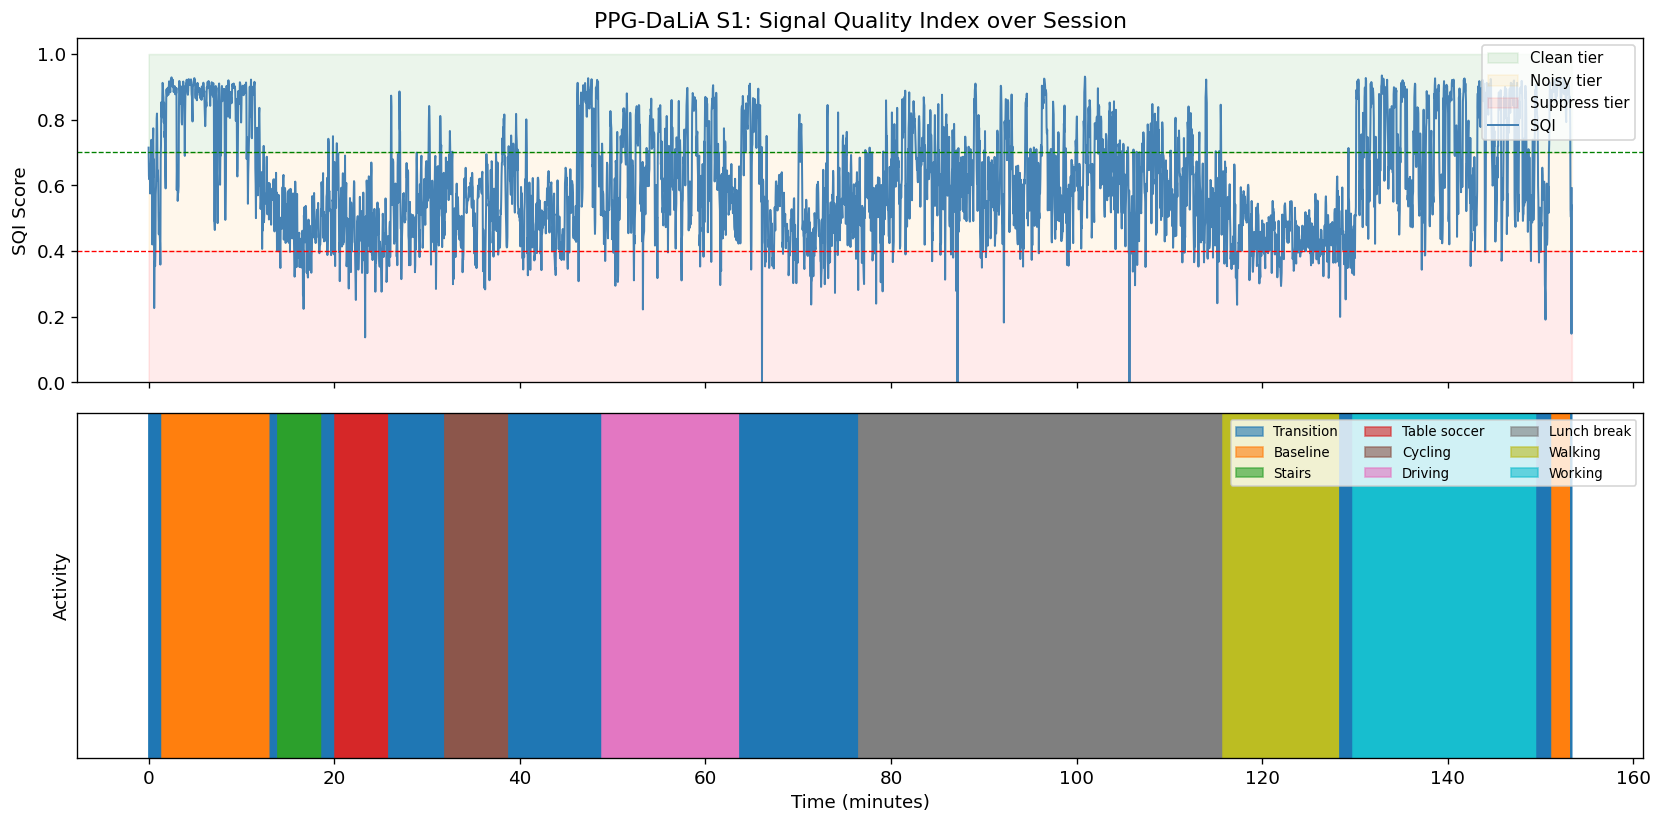

Saved: sqi_over_time.png


In [4]:
# --- Plot 1: SQI over time with activity labels ---

CLEAN_THRESH = 0.7
NOISY_THRESH = 0.4

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

# Top: SQI trace with tier bands
ax = axes[0]
ax.fill_between(window_times, CLEAN_THRESH, 1.0,  alpha=0.08, color='green',  label='Clean tier')
ax.fill_between(window_times, NOISY_THRESH, CLEAN_THRESH, alpha=0.08, color='orange', label='Noisy tier')
ax.fill_between(window_times, 0, NOISY_THRESH,    alpha=0.08, color='red',    label='Suppress tier')
ax.plot(window_times, sqis, color='steelblue', linewidth=1.2, label='SQI')
ax.axhline(CLEAN_THRESH, color='green', linewidth=0.8, linestyle='--')
ax.axhline(NOISY_THRESH, color='red',   linewidth=0.8, linestyle='--')
ax.set_ylabel('SQI Score')
ax.set_ylim(0, 1.05)
ax.legend(loc='upper right', fontsize=9)
ax.set_title(f'PPG-DaLiA {SUBJECT}: Signal Quality Index over Session')

# Bottom: activity label timeline
ax2 = axes[1]
unique_acts  = list(dict.fromkeys(window_acts))
cmap_colors  = plt.cm.tab10(np.linspace(0, 1, len(unique_acts)))
act_to_color = dict(zip(unique_acts, cmap_colors))

for i in range(len(window_times) - 1):
    ax2.axvspan(window_times[i], window_times[i+1],
                color=act_to_color[window_acts[i]], alpha=0.6)

handles = [plt.Rectangle((0,0),1,1, color=act_to_color[a], alpha=0.6) for a in unique_acts]
ax2.legend(handles, unique_acts, loc='upper right', fontsize=8, ncol=3)
ax2.set_xlabel('Time (minutes)')
ax2.set_ylabel('Activity')
ax2.set_yticks([])

plt.tight_layout()
plt.savefig('sqi_over_time.png', bbox_inches='tight')
plt.show()
print('Saved: sqi_over_time.png')

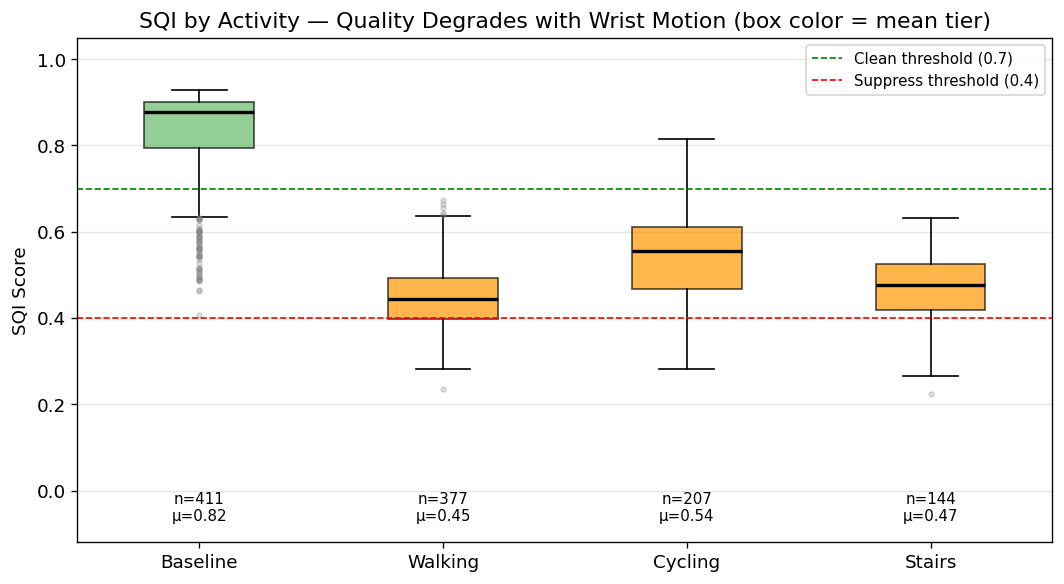


Mean SQI by activity:
  Baseline        mean=0.822  clean=83%  suppress=0%
  Walking         mean=0.451  clean=0%  suppress=27%
  Cycling         mean=0.541  clean=4%  suppress=12%
  Stairs          mean=0.469  clean=0%  suppress=19%


In [5]:
# --- Plot 2: SQI distribution by activity ---

TARGET_ACTS = ['Baseline', 'Walking', 'Cycling', 'Stairs']
act_sqis    = [sqis[window_acts == a] for a in TARGET_ACTS]
# Filter to activities that actually appear in this subject
TARGET_ACTS = [a for a, s in zip(TARGET_ACTS, act_sqis) if len(s) > 0]
act_sqis    = [s for s in act_sqis if len(s) > 0]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(act_sqis, tick_labels=TARGET_ACTS, patch_artist=True,
                medianprops=dict(color='black', linewidth=2),
                flierprops=dict(marker='o', markersize=3, alpha=0.25,
                                markerfacecolor='gray', markeredgecolor='gray'))

# Color each box by the tier its MEAN actually falls in (not by list position),
# so green/orange/red reflect real quality: clean >= 0.7, noisy 0.4-0.7, suppress < 0.4.
def tier_color(m):
    return '#66BB6A' if m >= CLEAN_THRESH else ('#FF9800' if m >= NOISY_THRESH else '#EF5350')
for patch, s in zip(bp['boxes'], act_sqis):
    patch.set_facecolor(tier_color(s.mean()))
    patch.set_alpha(0.7)

ax.axhline(CLEAN_THRESH, color='green', linestyle='--', linewidth=1,
           label=f'Clean threshold ({CLEAN_THRESH})')
ax.axhline(NOISY_THRESH, color='red', linestyle='--', linewidth=1,
           label=f'Suppress threshold ({NOISY_THRESH})')

for i, (act, s) in enumerate(zip(TARGET_ACTS, act_sqis)):
    ax.text(i + 1, -0.07, f'n={len(s)}\nμ={s.mean():.2f}', ha='center', fontsize=9)

ax.set_ylabel('SQI Score')
ax.set_ylim(-0.12, 1.05)
ax.set_title('SQI by Activity — Quality Degrades with Wrist Motion (box color = mean tier)')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('sqi_by_activity.png', bbox_inches='tight')
plt.show()

print('\nMean SQI by activity:')
for act, s in zip(TARGET_ACTS, act_sqis):
    pct_clean    = (s >= CLEAN_THRESH).mean() * 100
    pct_suppress = (s < NOISY_THRESH).mean() * 100
    print(f'  {act:<15} mean={s.mean():.3f}  clean={pct_clean:.0f}%  suppress={pct_suppress:.0f}%')

SQI–error correlation  : r = -0.425
Mean HR error by tier:
  Suppress (SQI < 0.4) : 19.1 bpm  (n=415)
  Noisy    (0.4–0.7)    : 15.6 bpm  (n=2864)
  Clean    (SQI ≥ 0.7) : 3.3 bpm  (n=1323)
  Error reduction clean vs suppress: 83%


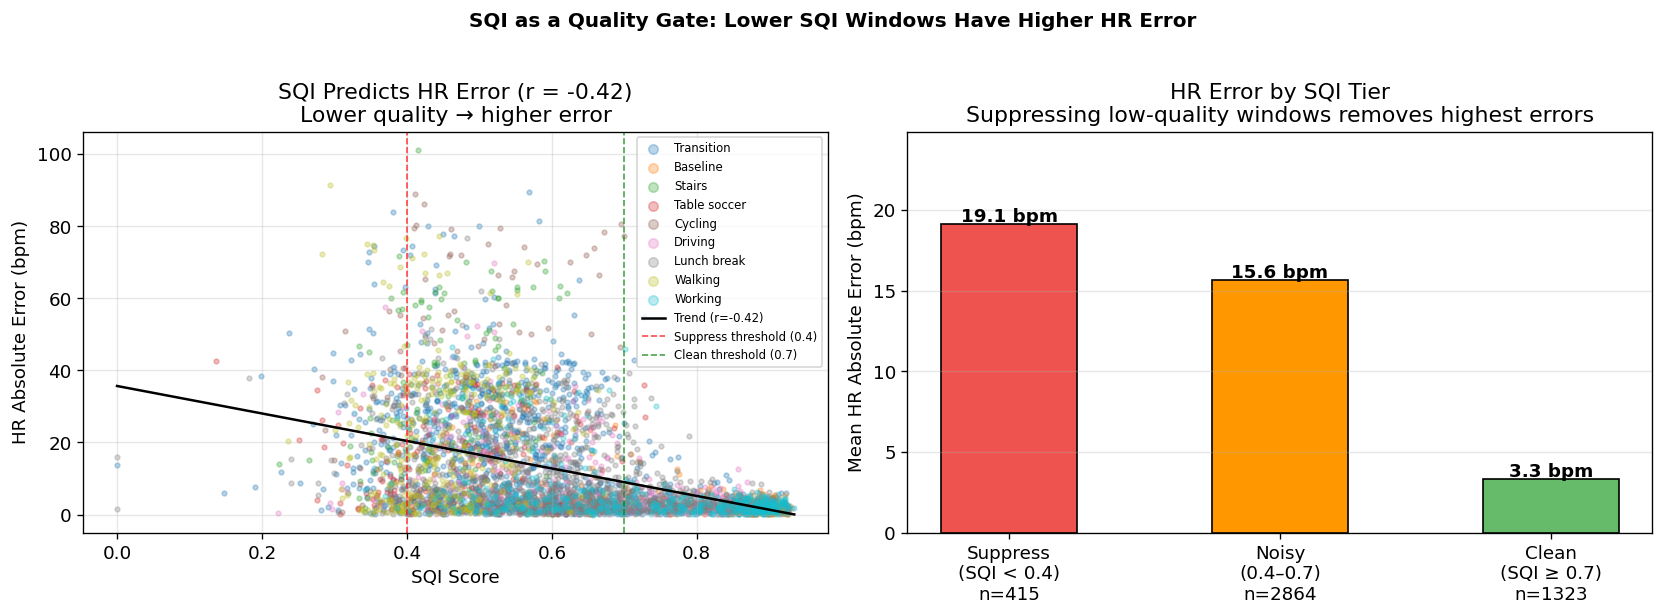

In [6]:
# --- Plot 3: SQI vs HR error — does SQI predict where the error is? ---
#
# This is the honest validation of the SQI concept:
# if SQI is a useful quality signal, windows with lower SQI should have higher HR error.
# A direct MAE comparison against Zhang 2015 (~2.3 bpm) would be misleading here —
# that benchmark used TROIKA's full sparse reconstruction on a controlled running protocol,
# not naive FFT peak picking across mixed daily-life activities. The right question is whether
# *our* SQI predicts *our* error, not whether we match a different algorithm on different data.

def fft_hr(ppg_win, fs):
    ppg_f   = bandpass(ppg_win, 0.5, 4.0, fs)
    N       = len(ppg_f)
    fft_mag = np.abs(np.fft.rfft(ppg_f * np.hanning(N)))
    freqs   = np.fft.rfftfreq(N, d=1/fs)
    cardiac = (freqs >= 0.5) & (freqs <= 4.0)
    return freqs[cardiac][np.argmax(fft_mag[cardiac])] * 60

CLEAN_THRESH = 0.7
NOISY_THRESH = 0.4

n_compare = min(len(sqis), len(gt_hr))
est_hrs   = np.array([fft_hr(ppg[i*STRIDE : i*STRIDE + WINDOW], fs_ppg)
                       for i in range(n_compare)])
gt_hrs    = gt_hr[:n_compare]
sqi_vals  = sqis[:n_compare]
acts_comp = window_acts[:n_compare]

valid = (gt_hrs > 30) & (gt_hrs < 220) & np.isfinite(est_hrs)
abs_err  = np.abs(est_hrs[valid] - gt_hrs[valid])
sqi_plot = sqi_vals[valid]
act_plot = acts_comp[valid]

# Correlation between SQI and HR error
corr = np.corrcoef(sqi_plot, abs_err)[0, 1]

# Mean error by SQI tier
suppress_err = abs_err[sqi_plot < NOISY_THRESH]
noisy_err    = abs_err[(sqi_plot >= NOISY_THRESH) & (sqi_plot < CLEAN_THRESH)]
clean_err    = abs_err[sqi_plot >= CLEAN_THRESH]

print(f'SQI–error correlation  : r = {corr:.3f}')
print(f'Mean HR error by tier:')
print(f'  Suppress (SQI < {NOISY_THRESH}) : {suppress_err.mean():.1f} bpm  (n={len(suppress_err)})')
print(f'  Noisy    ({NOISY_THRESH}–{CLEAN_THRESH})    : {noisy_err.mean():.1f} bpm  (n={len(noisy_err)})')
print(f'  Clean    (SQI ≥ {CLEAN_THRESH}) : {clean_err.mean():.1f} bpm  (n={len(clean_err)})')
print(f'  Error reduction clean vs suppress: {(suppress_err.mean()-clean_err.mean())/suppress_err.mean()*100:.0f}%')

# --- Scatter plot ---
unique_acts_plot = list(dict.fromkeys(act_plot))
act_colors       = dict(zip(unique_acts_plot,
                            plt.cm.tab10(np.linspace(0, 1, len(unique_acts_plot)))))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Left: scatter SQI vs HR error, coloured by activity
for act in unique_acts_plot:
    mask = act_plot == act
    ax1.scatter(sqi_plot[mask], abs_err[mask],
                color=act_colors[act], alpha=0.3, s=8, label=act)

# Trend line
m, b  = np.polyfit(sqi_plot, abs_err, 1)
xs    = np.linspace(sqi_plot.min(), sqi_plot.max(), 100)
ax1.plot(xs, m*xs + b, color='black', linewidth=1.5,
         label=f'Trend (r={corr:.2f})')
ax1.axvline(NOISY_THRESH, color='red',   linestyle='--', linewidth=1, alpha=0.7,
            label=f'Suppress threshold ({NOISY_THRESH})')
ax1.axvline(CLEAN_THRESH, color='green', linestyle='--', linewidth=1, alpha=0.7,
            label=f'Clean threshold ({CLEAN_THRESH})')
ax1.set_xlabel('SQI Score')
ax1.set_ylabel('HR Absolute Error (bpm)')
ax1.set_title(f'SQI Predicts HR Error (r = {corr:.2f})\nLower quality → higher error')
ax1.legend(fontsize=7, markerscale=2)
ax1.grid(alpha=0.3)

# Right: mean HR error by SQI tier
tier_labels = [f'Suppress\n(SQI < {NOISY_THRESH})\nn={len(suppress_err)}',
               f'Noisy\n({NOISY_THRESH}–{CLEAN_THRESH})\nn={len(noisy_err)}',
               f'Clean\n(SQI ≥ {CLEAN_THRESH})\nn={len(clean_err)}']
tier_means  = [suppress_err.mean(), noisy_err.mean(), clean_err.mean()]
tier_colors_bar = ['#EF5350', '#FF9800', '#66BB6A']

bars = ax2.bar(tier_labels, tier_means, color=tier_colors_bar,
               edgecolor='black', width=0.5)
for bar, val in zip(bars, tier_means):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
             f'{val:.1f} bpm', ha='center', fontsize=11, fontweight='bold')
ax2.set_ylabel('Mean HR Absolute Error (bpm)')
ax2.set_title('HR Error by SQI Tier\nSuppressing low-quality windows removes highest errors')
ax2.grid(axis='y', alpha=0.3)
ax2.set_ylim(0, max(tier_means) * 1.3)

plt.suptitle('SQI as a Quality Gate: Lower SQI Windows Have Higher HR Error',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('hr_mae_comparison.png', bbox_inches='tight')
plt.show()

---
### Cross-Subject Validation (all 15 subjects)

Part 1 ran on Subject S1. The honest question for any quality gate is whether it *generalizes*, so the same features run across all 15 PPG-DaLiA subjects below. Two checks: (1) does the gate **order the error correctly** for every subject — clean-tier HR error below suppress-tier — and (2) how much does performance vary between people? The same single pass also computes a **PPG–accelerometer coherence** feature used in the comparison further down.

*Note: this section loads and processes all 15 sessions, so it takes a few minutes to run.*

In [7]:
# --- Cross-subject feature extraction (all 15 subjects, single pass) ---
# Computes the SQI sub-features per 8 s window for every subject, plus the naive-FFT
# HR error vs ECG. One pass feeds both the tier-separation check and the coherence
# study below. (Loads all 15 sessions -- takes a few minutes.)
from scipy.signal import coherence as _coherence

def window_features(ppg_win, acc_win, fs):
    """(snr, autocorr, motion_proxy, coherence_penalty) for one window.
    Mirrors compute_sqi's three features and adds the coherence penalty."""
    ppg_w = bandpass(ppg_win, 0.5, 8.0, fs)
    freqs, psd = welch(ppg_w, fs=fs, nperseg=min(fs * 4, len(ppg_w)))
    band = (freqs >= 0.5) & (freqs <= 8.0)
    f, p = freqs[band], psd[band]
    card = (f >= 0.7) & (f <= 3.5)
    peak_f = f[card][np.argmax(p[card])]
    near = lambda c: (f >= c - 0.25) & (f <= c + 0.25)
    snr = float(np.clip((p[near(peak_f)].sum() + p[near(2 * peak_f)].sum())
                        / (p.sum() + 1e-9), 0, 1))
    ppg_f = bandpass(ppg_win, 0.5, 4.0, fs)
    ac = np.correlate(ppg_f, ppg_f, mode='full')[len(ppg_f) - 1:]
    ac = ac / (ac[0] + 1e-9)
    lo, hi = int(0.3 * fs), min(int(1.5 * fs), len(ac) - 1)
    autocorr = float(np.clip(ac[lo:hi].max() if hi > lo else 0.0, 0, 1))
    accmag = np.linalg.norm(acc_win, axis=1) if len(acc_win) else np.zeros(1)
    motion_std = float(accmag.std())
    motion = float(np.exp(-motion_std / 0.5))
    # coherence penalty: high PPG-ACC coherence at the cardiac peak => motion masquerading
    # as pulse (cadence lock). no-motion guard avoids NaN instability on still windows.
    if motion_std < 1e-3 or len(accmag) < 16:
        coh_pen = 1.0
    else:
        accmag_up = np.interp(np.linspace(0, 1, len(ppg_w)),
                              np.linspace(0, 1, len(accmag)), accmag)
        fco, cxy = _coherence(ppg_w, accmag_up, fs=fs, nperseg=min(fs * 2, len(ppg_w)))
        m = (fco >= peak_f - 0.25) & (fco <= peak_f + 0.25)
        coh_at_peak = float(np.nan_to_num(cxy[m].mean())) if m.any() else 0.0
        coh_pen = float(np.clip(1.0 - coh_at_peak, 0, 1))
    return snr, autocorr, motion, coh_pen

def extract_subject(subj):
    with open(f'data/PPG_FieldStudy/{subj}/{subj}.pkl', 'rb') as fh:
        d = pickle.load(fh, encoding='latin1')
    ppg_s = d['signal']['wrist']['BVP'].flatten()
    acc_s = d['signal']['wrist']['ACC']
    gt_s  = np.asarray(d['label']).flatten()
    feats, est = [], []
    for start in range(0, len(ppg_s) - WINDOW, STRIDE):
        pw = ppg_s[start:start + WINDOW]
        a0 = int(start * fs_acc / fs_ppg)
        aw = acc_s[a0:a0 + int(WINDOW * fs_acc / fs_ppg)]
        feats.append(window_features(pw, aw, fs_ppg))
        est.append(fft_hr(pw, fs_ppg))
    n = min(len(feats), len(gt_s))
    F = np.array(feats[:n]); e = np.array(est[:n]); gt = gt_s[:n]
    v = (gt > 30) & (gt < 220) & np.isfinite(e)
    return F[v], np.abs(e[v] - gt[v])

_m = lambda a: float(a.mean()) if len(a) else float('nan')   # safe mean (empty -> nan)

subjects = [f'S{i}' for i in range(1, 16)]
F_list, err_list, grp_list = [], [], []
for gi, s in enumerate(subjects):
    F, er = extract_subject(s)
    F_list.append(F); err_list.append(er); grp_list.append(np.full(len(er), gi))
    print(f'{s:>4}: {len(er):>5} windows')

F_all   = np.vstack(F_list)                                   # (N, 4): snr, autocorr, motion, coherence
err_all = np.concatenate(err_list)                            # (N,) naive-FFT HR abs error vs ECG
grp_all = np.concatenate(grp_list)                            # (N,) subject index 0..14
sqi_proxy = (F_all[:, 0] * F_all[:, 1] * F_all[:, 2]) ** (1 / 3)   # shipped heuristic SQI

rows = []
for gi, s in enumerate(subjects):
    msk = grp_all == gi
    sq, er = sqi_proxy[msk], err_all[msk]
    rows.append(dict(subj=s, r=float(np.corrcoef(sq, er)[0, 1]),
                     clean=_m(er[sq >= CLEAN_THRESH]), supp=_m(er[sq < NOISY_THRESH])))
pool_sqi, pool_r = sqi_proxy, float(np.corrcoef(sqi_proxy, err_all)[0, 1])
pc = _m(err_all[sqi_proxy >= CLEAN_THRESH])
pn = _m(err_all[(sqi_proxy >= NOISY_THRESH) & (sqi_proxy < CLEAN_THRESH)])
ps = _m(err_all[sqi_proxy < NOISY_THRESH])
n_ok = sum(1 for x in rows if x['supp'] > x['clean'])

print(f'\nTotal windows: {len(err_all):,}  across {len(subjects)} subjects')
print(f'Pooled clean {pc:.1f} / noisy {pn:.1f} / suppress {ps:.1f} bpm '
      f'({100*(ps-pc)/ps:.0f}% reduction)')
print(f'Gate orders error correctly (clean < suppress): {n_ok}/15 subjects')
print(f'Per-subject r: mean {np.mean([x["r"] for x in rows]):.3f} '
      f'[{min(x["r"] for x in rows):.3f}, {max(x["r"] for x in rows):.3f}]')

  S1:  4602 windows
  S2:  4099 windows
  S3:  4367 windows
  S4:  4571 windows
  S5:  4649 windows
  S6:  2621 windows
  S7:  4668 windows
  S8:  4036 windows
  S9:  4276 windows
 S10:  5320 windows
 S11:  4520 windows
 S12:  3953 windows
 S13:  4564 windows
 S14:  4475 windows
 S15:  3966 windows

Total windows: 64,687  across 15 subjects
Pooled clean 4.9 / noisy 22.9 / suppress 27.5 bpm (82% reduction)
Gate orders error correctly (clean < suppress): 15/15 subjects
Per-subject r: mean -0.373 [-0.456, -0.257]


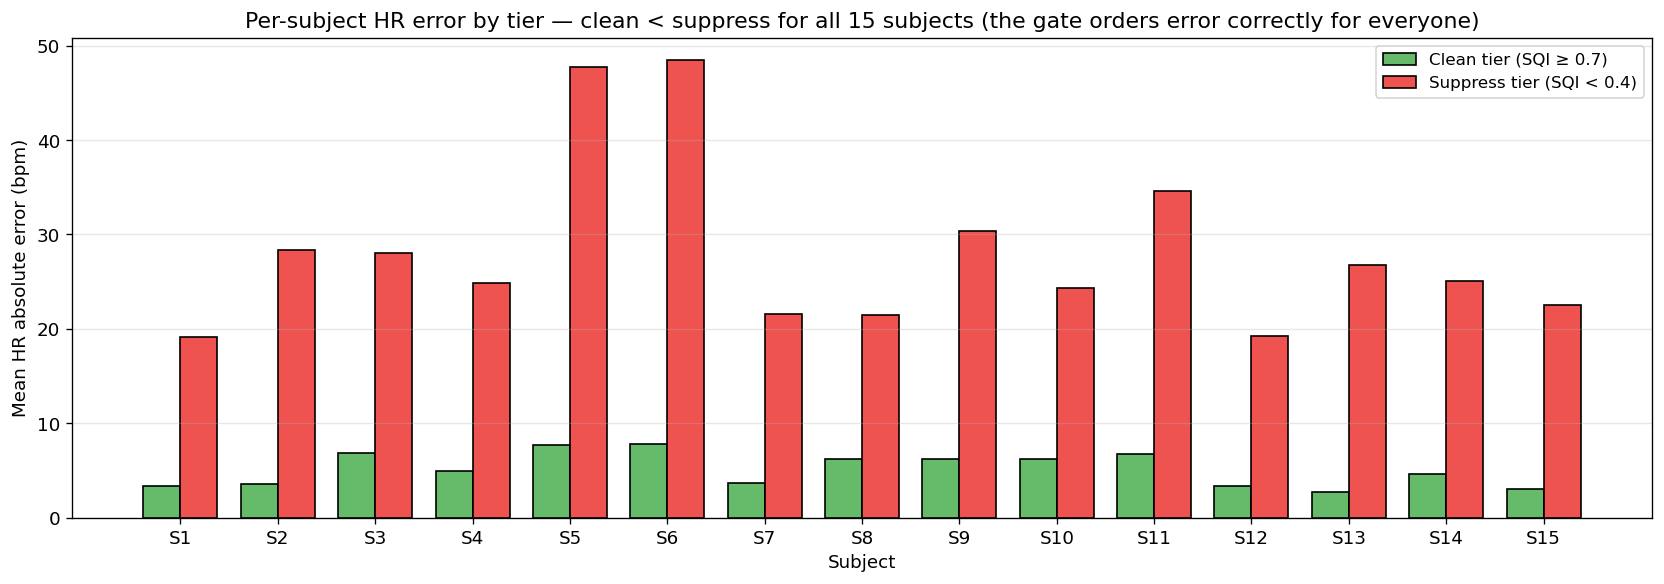

Saved: sqi_cross_subject.png


In [8]:
# --- Cross-subject viz 1: per-subject clean vs suppress error ---
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(rows)); w = 0.38
ax.bar(x - w/2, [r['clean'] for r in rows], w, label='Clean tier (SQI ≥ 0.7)',
       color='#66BB6A', edgecolor='black')
ax.bar(x + w/2, [r['supp'] for r in rows], w, label='Suppress tier (SQI < 0.4)',
       color='#EF5350', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels([r['subj'] for r in rows])
ax.set_xlabel('Subject'); ax.set_ylabel('Mean HR absolute error (bpm)')
ax.set_title('Per-subject HR error by tier — clean < suppress for all 15 subjects '
             '(the gate orders error correctly for everyone)')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('sqi_cross_subject.png', bbox_inches='tight')
plt.show()
print('Saved: sqi_cross_subject.png')

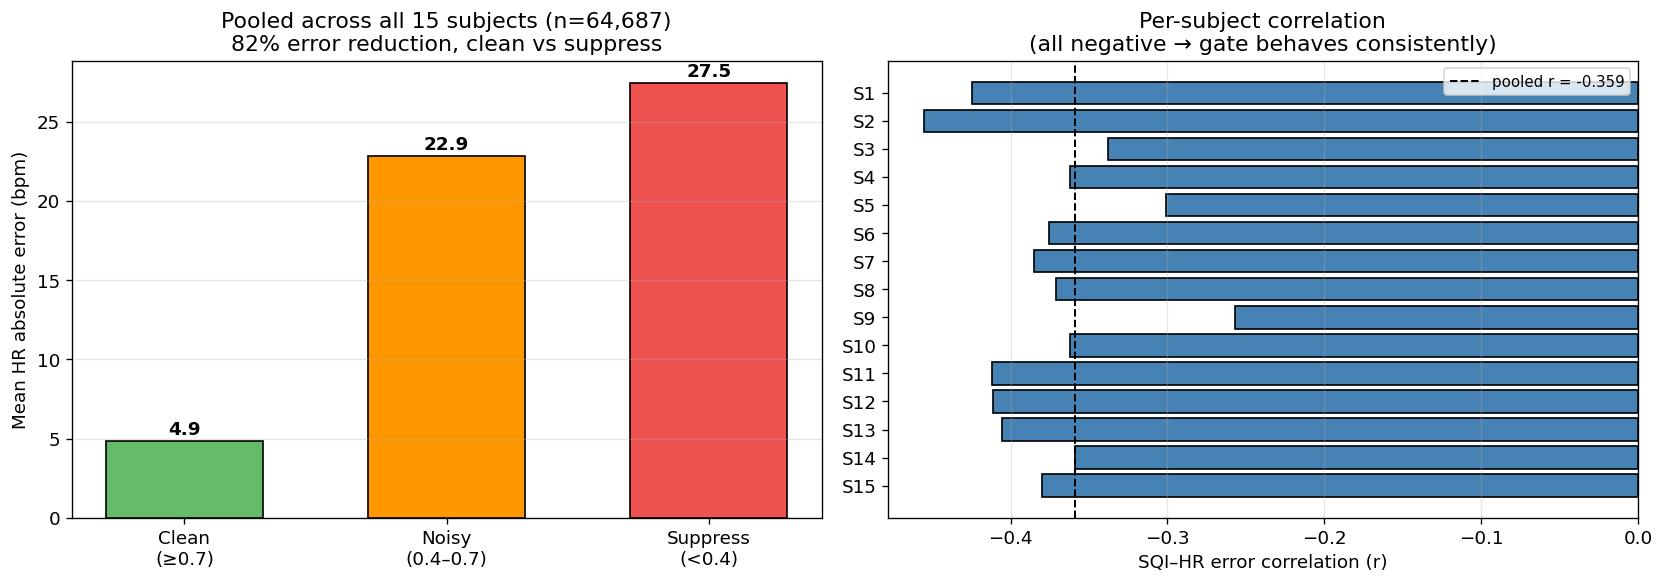

Saved: sqi_cross_subject_summary.png


In [9]:
# --- Cross-subject viz 2: pooled tiers + per-subject correlation spread ---
fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 5))

axA.bar(['Clean\n(≥0.7)', 'Noisy\n(0.4–0.7)', 'Suppress\n(<0.4)'], [pc, pn, ps],
        color=['#66BB6A', '#FF9800', '#EF5350'], edgecolor='black', width=0.6)
for i, v in enumerate([pc, pn, ps]):
    axA.text(i, v + 0.4, f'{v:.1f}', ha='center', fontsize=11, fontweight='bold')
axA.set_ylabel('Mean HR absolute error (bpm)')
axA.set_title(f'Pooled across all 15 subjects (n={len(pool_sqi):,})\n'
              f'{100*(ps-pc)/ps:.0f}% error reduction, clean vs suppress')
axA.grid(axis='y', alpha=0.3)

rs = [r['r'] for r in rows]
axB.barh([r['subj'] for r in rows], rs, color='steelblue', edgecolor='black')
axB.axvline(pool_r, color='black', linestyle='--', linewidth=1.2,
            label=f'pooled r = {pool_r:.3f}')
axB.set_xlabel('SQI–HR error correlation (r)')
axB.set_title('Per-subject correlation\n(all negative → gate behaves consistently)')
axB.legend(fontsize=9); axB.grid(axis='x', alpha=0.3); axB.invert_yaxis()
plt.tight_layout()
plt.savefig('sqi_cross_subject_summary.png', bbox_inches='tight')
plt.show()
print('Saved: sqi_cross_subject_summary.png')

---
### Where Should the Tier Cutoffs Be? (reading them off the error curve)

The 0.7 and 0.4 cutoffs were placeholders. The principled way to set them is from the **downstream error budget**: bin HR error by SQI level across all 15 subjects and read each boundary off where error crosses an acceptable bound.

What the curve below actually shows: HR error declines smoothly and collapses across the **0.7–0.85** band. So the 0.7 clean cutoff catches the *start* of that collapse but is **lenient** — a window sitting right at SQI 0.7 still carries ~16 bpm error. The clean-tier mean (4.9 bpm) looks low only because clean windows cluster well *above* the threshold, not because 0.7 itself is clean. Read off the budget instead: 5 bpm needs SQI ≥ 0.83, 10 bpm ≥ 0.78, 15 bpm ≥ 0.73 — so for a strict accuracy target I'd move the clean cutoff toward 0.83.

The 0.4 suppress boundary isn't pinned by this demo at all: it's meant to gate "recoverable vs not," and the naive estimator never runs the adaptive-filter recovery that would show its payoff. In production both cutoffs would be operating points on this curve, tuned to a target false-clean rate and calibrated per user.

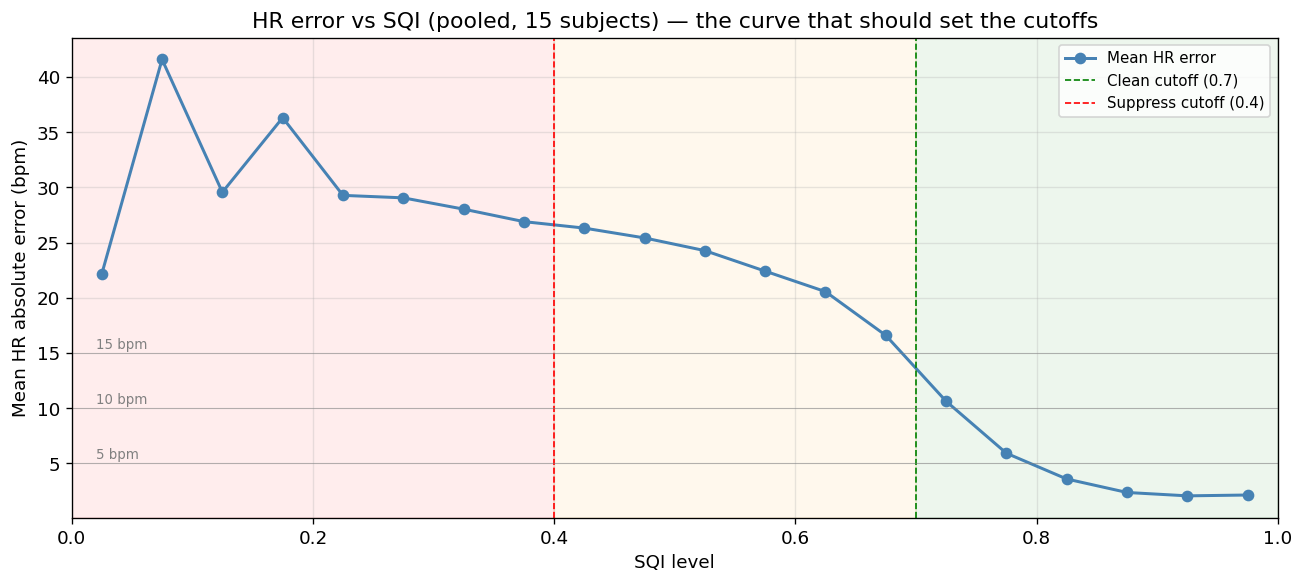

Saved: sqi_threshold_curve.png
mean error <=  5 bpm for SQI >= 0.83
mean error <= 10 bpm for SQI >= 0.78
mean error <= 15 bpm for SQI >= 0.73


In [10]:
# --- Error vs SQI: are the 0.7 / 0.4 cutoffs in the right place? ---
# Bin the pooled per-window HR error by SQI level (shipped heuristic) across all 15 subjects.
bins = np.linspace(0, 1, 21)                      # 0.05-wide SQI bins
centers = 0.5 * (bins[:-1] + bins[1:])
binidx = np.clip(np.digitize(sqi_proxy, bins) - 1, 0, len(centers) - 1)
mean_err = np.array([_m(err_all[binidx == b]) for b in range(len(centers))])

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(centers, mean_err, marker='o', color='steelblue', linewidth=1.8, label='Mean HR error')
ax.axvspan(0.7, 1.0, alpha=0.07, color='green')
ax.axvspan(0.4, 0.7, alpha=0.07, color='orange')
ax.axvspan(0.0, 0.4, alpha=0.07, color='red')
ax.axvline(0.7, color='green', linestyle='--', linewidth=1, label='Clean cutoff (0.7)')
ax.axvline(0.4, color='red',   linestyle='--', linewidth=1, label='Suppress cutoff (0.4)')
for budget in (5, 10, 15):
    ax.axhline(budget, color='gray', linewidth=0.6, alpha=0.5)
    ax.text(0.02, budget + 0.4, f'{budget} bpm', fontsize=8, color='gray')
ax.set_xlabel('SQI level'); ax.set_ylabel('Mean HR absolute error (bpm)')
ax.set_title('HR error vs SQI (pooled, 15 subjects) — the curve that should set the cutoffs')
ax.set_xlim(0, 1); ax.legend(fontsize=9, loc='upper right'); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('sqi_threshold_curve.png', bbox_inches='tight')
plt.show()
print('Saved: sqi_threshold_curve.png')

# read candidate cutoffs off the curve: lowest SQI where mean error stays under each budget
for budget in (5, 10, 15):
    ok = centers[(mean_err <= budget) & np.isfinite(mean_err)]
    print(f'mean error <= {budget:>2} bpm for SQI >= {ok.min():.2f}' if len(ok)
          else f'mean error never <= {budget} bpm')

---
### Feature Study: Coherence vs. the Motion-Magnitude Proxy (a tested hypothesis)

The shipped motion feature only asks *how much* the wrist moves (`exp(-std)`). It misses the worst PPG failure — **cadence lock** — where motion at cardiac frequency (e.g. running cadence ≈ heart rate) injects a sharp, periodic oscillation that the SNR and autocorrelation features happily score as a clean pulse. PPG–accelerometer **coherence at the cardiac peak** targets exactly that: high coherence there means the "pulse" is tracking motion.

**Hypothesis:** swapping the motion proxy for the coherence penalty improves tier separation. **Result (below):** across all 15 subjects it is slightly *worse* (clean→suppress gap 22.6 → 21.4 bpm, r −0.36 → −0.33) — even though it looked slightly *better* on S1 alone, a second reminder that single-subject wins don't generalize. The reason is mechanistic: **PPG-DaLiA contains no running**, which is the cadence-lock scenario coherence is built to catch, so here its extra estimator variance just adds noise with no failure mode to offset it. So I keep it as a documented experiment with an honest negative result, *not* a shipped feature — I'd re-test it on running-heavy data where the target failure actually occurs. (The no-motion guard keeps it numerically stable: 0 NaNs.)

feature                   clean    supp     gap       r
motion proxy (shipped)      4.9    27.5    22.6  -0.359
coherence variant           5.5    26.9    21.4  -0.333

NaNs in coherence feature: 0  (no-motion guard holds)


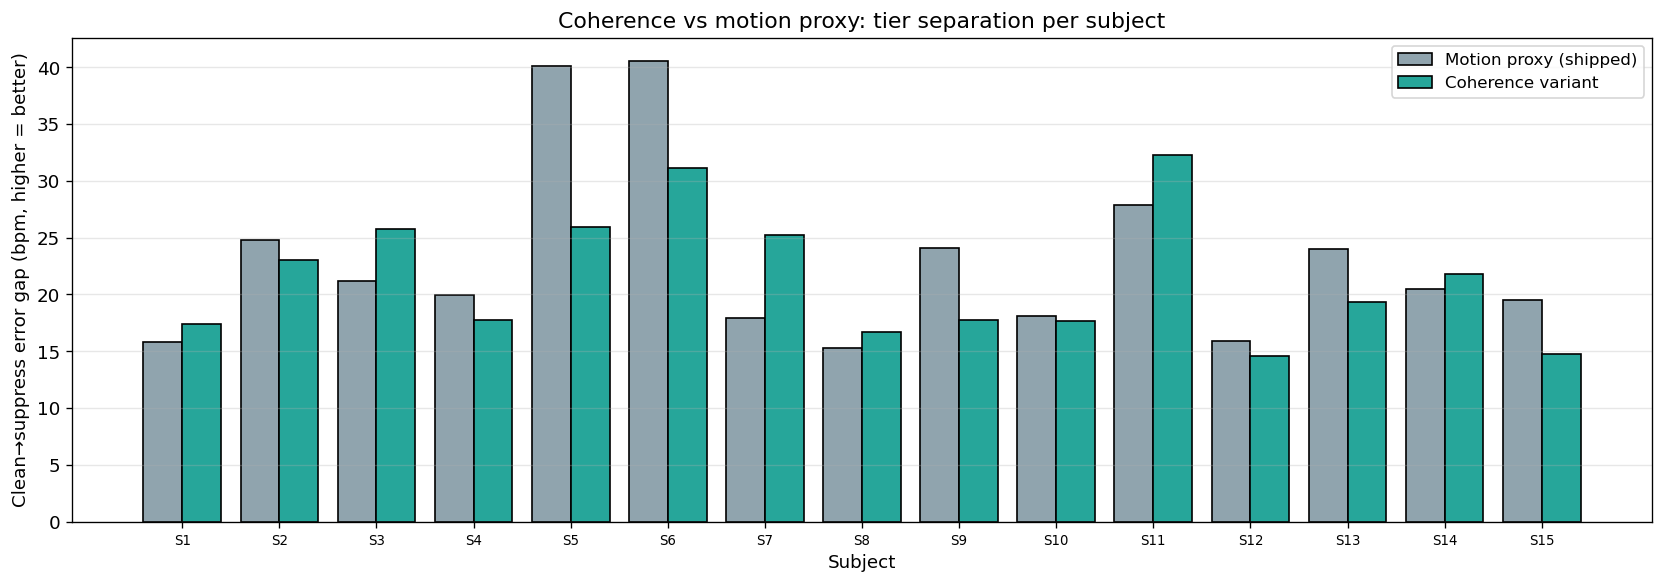

Saved: sqi_coherence_compare.png


In [11]:
# --- Coherence vs motion proxy: tier separation across all 15 subjects ---
sqi_coh = (F_all[:, 0] * F_all[:, 1] * F_all[:, 3]) ** (1 / 3)   # swap motion -> coherence

def tier_stats(score):
    return (_m(err_all[score >= CLEAN_THRESH]), _m(err_all[score < NOISY_THRESH]),
            float(np.corrcoef(score, err_all)[0, 1]))

print(f'{"feature":<24}{"clean":>7}{"supp":>8}{"gap":>8}{"r":>8}')
for name, score in [('motion proxy (shipped)', sqi_proxy), ('coherence variant', sqi_coh)]:
    c, s, r = tier_stats(score)
    print(f'{name:<24}{c:>7.1f}{s:>8.1f}{s-c:>8.1f}{r:>8.3f}')
print(f'\nNaNs in coherence feature: {int(np.isnan(F_all[:, 3]).sum())}  (no-motion guard holds)')

# per-subject clean->suppress gap (suppress error minus clean error; higher = better)
def gap(score, gi):
    msk = grp_all == gi
    return _m(err_all[msk & (score < NOISY_THRESH)]) - _m(err_all[msk & (score >= CLEAN_THRESH)])
gap_proxy = [gap(sqi_proxy, gi) for gi in range(len(subjects))]
gap_coh   = [gap(sqi_coh, gi)   for gi in range(len(subjects))]

fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(len(subjects)); w = 0.4
ax.bar(x - w/2, gap_proxy, w, label='Motion proxy (shipped)', color='#90A4AE', edgecolor='black')
ax.bar(x + w/2, gap_coh,   w, label='Coherence variant',      color='#26A69A', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(subjects, fontsize=8)
ax.set_xlabel('Subject'); ax.set_ylabel('Clean→suppress error gap (bpm, higher = better)')
ax.set_title('Coherence vs motion proxy: tier separation per subject')
ax.legend(fontsize=10); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('sqi_coherence_compare.png', bbox_inches='tight')
plt.show()
print('Saved: sqi_coherence_compare.png')

---
## Part 2: IMU Demo — Rep Counting and Velocity Drift (Q2)

Two synthetic examples that sit on either side of the feasible / hard-but-learnable line:

1. **Rep counting** — peak detection on filtered ACC. Feasible.
2. **Velocity via integration** — the number you want for VBT is concentric velocity, which decays as a set approaches failure. But integrating acceleration turns a small accelerometer bias into velocity drift that grows with time. Near failure the true velocity is small and the rep is long, so the *relative* drift error is largest exactly where the VBT signal is most informative. That tension — most informative, least reliable — is the point.

Synthetic data keeps the drift mechanism visible and unambiguous. Real bar-path velocity has more going on (orientation/gravity leakage dominates real drift), but the relative-error story is the same.

In [12]:
np.random.seed(42)
FS = 100   # Hz
G  = 9.81

# A set taken to failure. Two things happen as the lifter fatigues, both real:
#   - concentric velocity decays rep to rep   <- this IS the VBT failure signal
#   - reps get slower / longer in duration    <- this is what makes drift worse
n_reps  = 11
vpeak   = np.linspace(0.85, 0.30, n_reps)   # m/s, mean concentric velocity per rep
rep_dur = np.linspace(0.90, 1.70, n_reps)   # s,   rep duration grows near failure

# Build a continuous vertical-acceleration signal, rep by rep.
acc_true, vel_true, bounds = [], [], [0.0]
t = 0.0
for i in range(n_reps):
    m  = int(rep_dur[i] * FS)
    tt = np.linspace(0, rep_dur[i], m)
    v  = vpeak[i] * np.sin(np.pi * tt / rep_dur[i])   # half-sine, ~0 at rep ends
    vel_true.append(v)
    acc_true.append(np.gradient(v, 1 / FS))
    t += rep_dur[i]
    bounds.append(t)
acc_true  = np.concatenate(acc_true)
vel_true  = np.concatenate(vel_true)
t_all     = np.arange(len(acc_true)) / FS
bound_idx = [int(b * FS) for b in bounds]

# --- Rep counting via peak detection (FEASIBLE) ---
def count_reps(acc, fs=FS):
    b, a = butter(4, [0.3/(fs/2), 3.0/(fs/2)], btype='band')
    f = filtfilt(b, a, acc)
    peaks, _ = find_peaks(f, height=np.std(f) * 0.5, distance=int(0.4 * fs))
    return peaks, f

peaks, filtered = count_reps(acc_true)
print(f'Reps detected: {len(peaks)}  (constructed: {n_reps})')

# --- Velocity by integration, and the drift that corrupts it (HARD BUT LEARNABLE) ---
# Error source: a small constant accelerometer bias. Integrated, it becomes velocity
# drift that grows ~ bias * t, independent of the true motion.
BIAS      = 0.015 * G                                    # 0.015 g unmodeled offset
acc_meas  = acc_true + BIAS + 0.05 * np.random.randn(len(acc_true))
vel_naive = np.cumsum(acc_meas) / FS                     # drifts away

# ZUPT: velocity is ~0 at each rep boundary, so detrend per rep to bound the drift.
vel_zupt = vel_naive.copy()
for i in range(len(bound_idx) - 1):
    sl  = slice(bound_idx[i], bound_idx[i+1])
    seg = vel_zupt[sl]
    if len(seg) > 1:
        vel_zupt[sl] = seg - np.linspace(seg[0], seg[-1], len(seg))

# Per-rep confidence from RELATIVE drift error, not raw speed. A per-rep linear ZUPT
# removes most of a *constant* bias (a bias integrates to a linear velocity ramp, which
# the detrend cancels). What survives is the fraction EPS of the bias we can't calibrate
# away, leaving a residual velocity drift ~ EPS * bias * T  (units m/s -- a velocity, so
# rel_err below is properly dimensionless). Dividing by the shrinking true velocity makes
# the relative error grow near failure: same small drift, smaller signal. We still REPORT
# the low velocity (it is the signal) -- we just widen its error bars.
EPS       = 0.10                                         # fraction of bias left after ZUPT
rep_drift = EPS * BIAS * rep_dur                         # m/s, residual velocity drift
rel_err   = rep_drift / vpeak                            # dimensionless
rep_conf  = np.clip(1 - rel_err / 0.25, 0, 1)            # 25% relative-error budget
loss_thr  = 0.6 * vpeak[0]                               # 40% velocity loss = VBT failure

print('rep  vel(m/s)  dur(s)  drift(cm/s)  rel_err  confidence')
for i in range(n_reps):
    print(f'  {i+1:2d}    {vpeak[i]:.2f}    {rep_dur[i]:.2f}      '
          f'{rep_drift[i]*100:4.1f}        {rel_err[i]*100:3.0f}%      {rep_conf[i]:.2f}')
print(f'40% velocity-loss threshold ({loss_thr:.2f} m/s) first crossed at rep '
      f'{int(np.argmax(vpeak < loss_thr) + 1)}')

Reps detected: 11  (constructed: 11)
rep  vel(m/s)  dur(s)  drift(cm/s)  rel_err  confidence
   1    0.85    0.90       1.3          2%      0.94
   2    0.79    0.98       1.4          2%      0.93
   3    0.74    1.06       1.6          2%      0.92
   4    0.68    1.14       1.7          2%      0.90
   5    0.63    1.22       1.8          3%      0.89
   6    0.57    1.30       1.9          3%      0.87
   7    0.52    1.38       2.0          4%      0.84
   8    0.46    1.46       2.1          5%      0.82
   9    0.41    1.54       2.3          6%      0.78
  10    0.35    1.62       2.4          7%      0.73
  11    0.30    1.70       2.5          8%      0.67
40% velocity-loss threshold (0.51 m/s) first crossed at rep 8


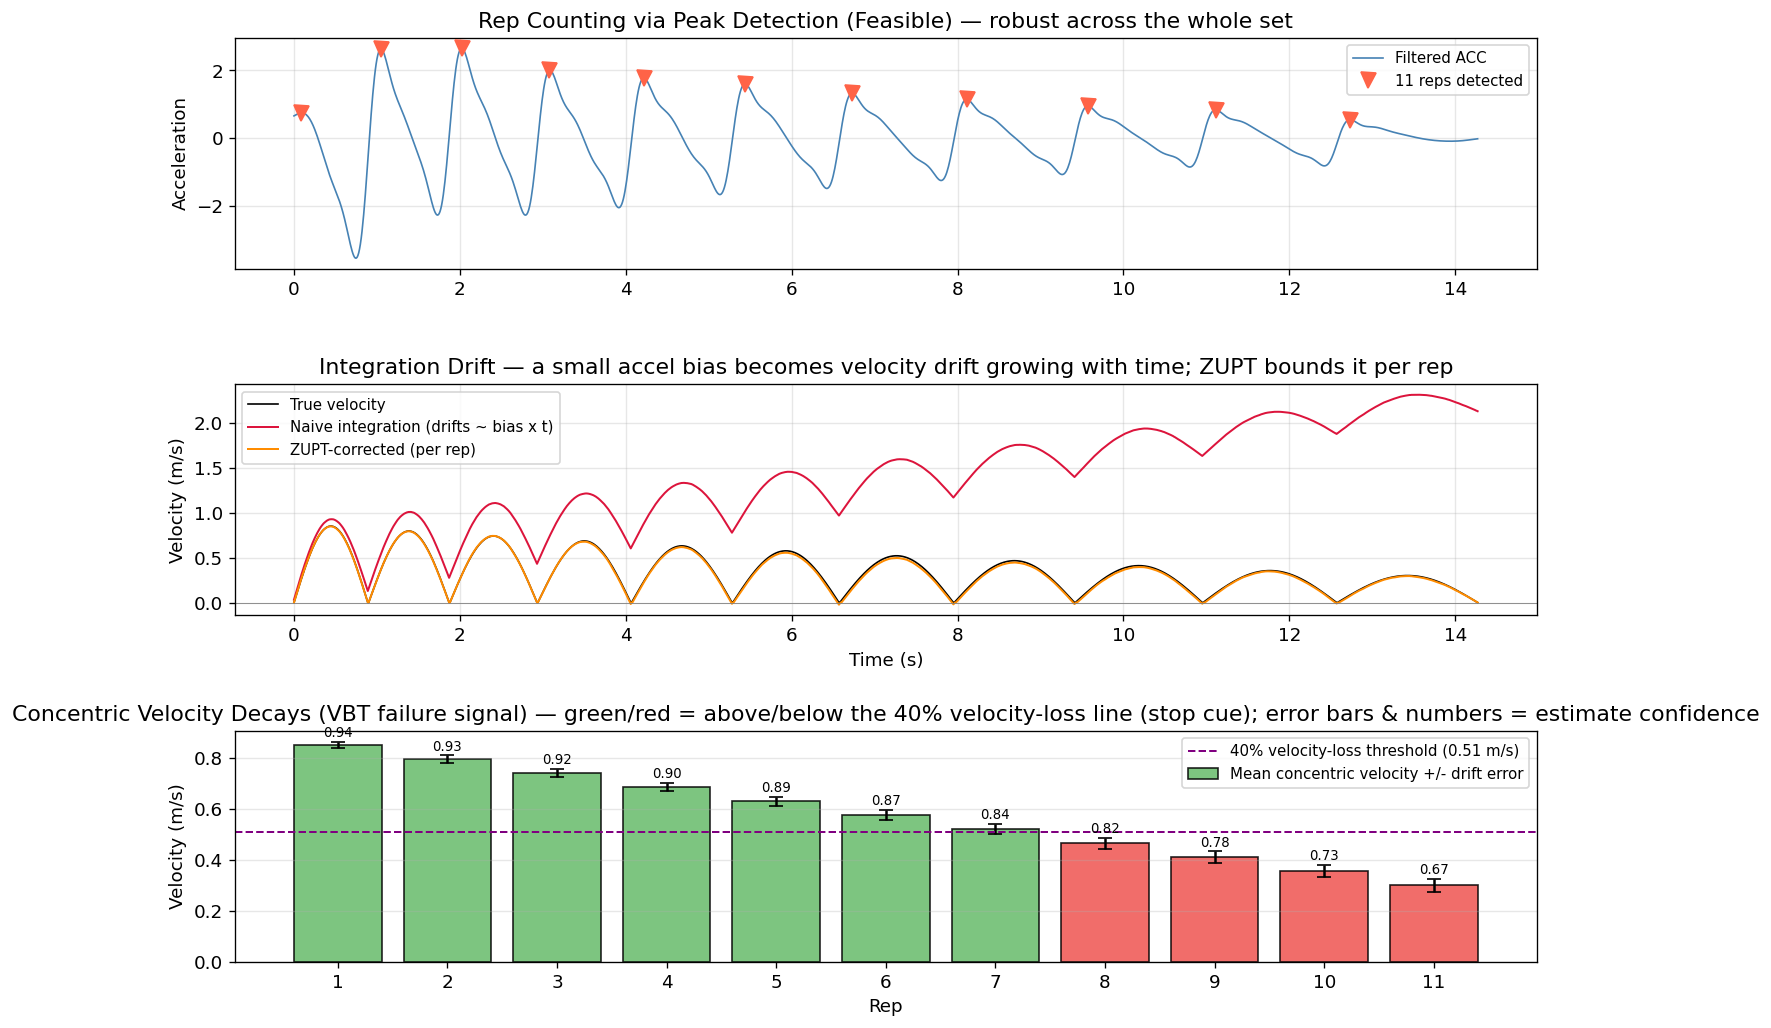

Saved: imu_rep_velocity.png


In [13]:
# --- Plot: rep counting + integration drift + per-rep velocity with drift bars ---

fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(3, 1, hspace=0.5)

# Panel 1: rep counting
ax1 = fig.add_subplot(gs[0])
ax1.plot(t_all, filtered, color='steelblue', linewidth=1, label='Filtered ACC')
ax1.plot(t_all[peaks], filtered[peaks], 'v', color='tomato', markersize=9,
         label=f'{len(peaks)} reps detected', zorder=5)
ax1.set_ylabel('Acceleration')
ax1.set_title('Rep Counting via Peak Detection (Feasible) — robust across the whole set')
ax1.legend(fontsize=9, loc='upper right'); ax1.grid(alpha=0.3)

# Panel 2: integration drift and its correction
ax2 = fig.add_subplot(gs[1], sharex=ax1)
ax2.plot(t_all, vel_true,  color='black',     linewidth=1.0, label='True velocity')
ax2.plot(t_all, vel_naive, color='crimson',   linewidth=1.2, label='Naive integration (drifts ~ bias x t)')
ax2.plot(t_all, vel_zupt,  color='darkorange', linewidth=1.2, label='ZUPT-corrected (per rep)')
ax2.axhline(0, color='gray', linewidth=0.5)
ax2.set_ylabel('Velocity (m/s)'); ax2.set_xlabel('Time (s)')
ax2.set_title('Integration Drift — a small accel bias becomes velocity drift growing with time; ZUPT bounds it per rep')
ax2.legend(fontsize=9, loc='upper left'); ax2.grid(alpha=0.3)

# Panel 3: per-rep concentric velocity. Bar color = the stop/continue decision (above/below
# the 40% velocity-loss line), so color AGREES with position. Confidence lives in the error
# bars (drift) and the number labels -- one encoding per idea, no color/line conflict.
ax3 = fig.add_subplot(gs[2])
reps = np.arange(1, n_reps + 1)
bar_colors = ['#66BB6A' if v >= loss_thr else '#EF5350' for v in vpeak]
ax3.bar(reps, vpeak, yerr=rep_drift, capsize=4,
        color=bar_colors, edgecolor='black', alpha=0.85,
        label='Mean concentric velocity +/- drift error')
ax3.axhline(loss_thr, color='purple', linestyle='--', linewidth=1.2,
            label=f'40% velocity-loss threshold ({loss_thr:.2f} m/s)')
for i in range(n_reps):
    ax3.text(reps[i], vpeak[i] + rep_drift[i] + 0.02, f'{rep_conf[i]:.2f}',
             ha='center', fontsize=8)
ax3.set_xlabel('Rep'); ax3.set_ylabel('Velocity (m/s)'); ax3.set_xticks(reps)
ax3.set_title('Concentric Velocity Decays (VBT failure signal) — green/red = above/below the 40% '
              'velocity-loss line (stop cue); error bars & numbers = estimate confidence')
ax3.legend(fontsize=9, loc='upper right'); ax3.grid(axis='y', alpha=0.3)

plt.savefig('imu_rep_velocity.png', bbox_inches='tight')
plt.show()
print('Saved: imu_rep_velocity.png')

---
## Summary of Results

**SQI pipeline (Q3)**

`sqi_over_time.png` — SQI drops when higher-motion activities begin and recovers at rest; the clean / noisy / suppress bands are visible as the signal moves between activities.

`sqi_by_activity.png` — SQI follows the expected ordering, but note it tracks **wrist** motion, not exertion: cycling (hands fixed on the bars) scores higher than walking or stairs (free arm swing). Box color reflects each activity's actual mean tier.

`hr_mae_comparison.png` — SQI negatively correlates with HR error (r ~ -0.42): lower-quality windows have higher error, lowest in the clean tier and highest in suppress. Absolute error reflects naive FFT peak picking — the claim is that *SQI predicts where the error is*, not that it matches a tuned HR algorithm.

`sqi_cross_subject.png` / `sqi_cross_subject_summary.png` — the S1 result holds across **all 15 subjects**: the gate orders error correctly (clean < suppress) for every subject (pooled 4.9 vs 27.5 bpm, ~82% reduction), with honest between-subject variance that argues for per-user threshold calibration.

`sqi_threshold_curve.png` — HR error binned by SQI level across the 15 subjects: the curve that *should* set the cutoffs instead of round numbers. It shows error collapsing across the 0.7–0.85 band — so the 0.7 clean cutoff is in the right region but lenient (a window at 0.7 is still ~16 bpm off; a 5 bpm budget points to ~0.83). The 0.4 suppress boundary isn't pinned by this demo, since the naive estimator never runs the noisy-tier recovery the 0.4 cut is meant to gate.

`sqi_coherence_compare.png` — a tested hypothesis with an honest negative result: PPG–ACC coherence (built to catch cadence-lock) is slightly *worse* than the motion proxy across the 15 subjects, because DaLiA has no running for it to catch. Kept as a documented experiment, not shipped.

**IMU demo (Q2)**

`imu_rep_velocity.png` — Rep counting via bandpass + peak detection is robust across the set (feasible). Concentric velocity decays toward failure (the VBT signal); integration drift from a constant accel bias grows with time and is bounded per rep by ZUPT. Error bars widen near failure because the *relative* drift grows there — the product response is wider error bars on late reps, not hiding them.